# NLP Lab 3 — Tokenizer Vocabulary Size vs F1
Автоматически сформировано ChatGPT.  

**Структура изменений**  
1. Импорты вынесены в отдельную ячейку.  
2. Константы собраны в одном месте.  
3. Функции/классы объявлены до основной логики.

In [1]:
import random
from pathlib import Path
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
import lightning.pytorch as pl
from datasets import Dataset, DatasetDict
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
import torchmetrics
import matplotlib.pyplot as plt

In [15]:
RANDOM_SEED = 42
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
VOCAB_SIZES = [2000, 5000, 10000, 20000]
MAX_LENGTH = 128

DATA_PATH = Path('text_with_morph_features.csv')
TEXT_COLUMN = 'normalized_text'
LABEL_COLUMN = 'type'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

pl.seed_everything(RANDOM_SEED)

Seed set to 42


42

In [3]:
DEVICE

'cuda'

In [4]:
def build_tokenizer(texts, vocab_size):
    """Train a simple BPE tokenizer."""
    tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=['[PAD]', '[UNK]'])
    tokenizer.train_from_iterator(texts, trainer=trainer)
    return tokenizer

class MyDataModule(pl.LightningDataModule):
    def __init__(self, dataset: DatasetDict, tokenizer: Tokenizer):
        super().__init__()
        self.dataset = dataset
        self.tokenizer = tokenizer

    def collate_fn(self, batch):
        texts = [x[TEXT_COLUMN] for x in batch]
        labels = torch.tensor([x[LABEL_COLUMN] for x in batch], dtype=torch.long)
        encodings = self.tokenizer.encode_batch(texts)
        input_ids = [enc.ids[:MAX_LENGTH] + [0]*(MAX_LENGTH - len(enc.ids[:MAX_LENGTH])) for enc in encodings]
        return {'input_ids': torch.tensor(input_ids, dtype=torch.long), 'label': labels}

    def train_dataloader(self):
        return DataLoader(self.dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=self.collate_fn)

    def val_dataloader(self):
        return DataLoader(self.dataset['validation'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=self.collate_fn)

class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_classes=2):
        super().__init__()
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.f1 = torchmetrics.F1Score(task='binary', threshold=0.5)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        _, h = self.gru(x)
        return self.fc(h.squeeze(0))

    def training_step(self, batch, _):
        logits = self(batch['input_ids'])
        loss = nn.functional.cross_entropy(logits, batch['label'])
        preds = torch.argmax(logits, dim=1)
        f1 = self.f1(preds, batch['label'])
        self.log_dict({'train_loss': loss, 'train_f1': f1}, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        logits = self(batch['input_ids'])
        loss = nn.functional.cross_entropy(logits, batch['label'])
        preds = torch.argmax(logits, dim=1)
        f1 = self.f1(preds, batch['label'])
        self.log_dict({'val_loss': loss, 'val_f1': f1}, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=LEARNING_RATE)

In [7]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows")

Loaded 223846 rows


In [21]:
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype('category')
df = df[df[TEXT_COLUMN].notnull()].copy()
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)

C:\Users\mrkaz\AppData\Local\Temp\ipykernel_14284\1554771070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[LABEL_COLUMN] = df[LABEL_COLUMN].astype('category')


In [22]:
dataset = Dataset.from_pandas(df)
dataset = dataset.class_encode_column(LABEL_COLUMN)
dataset = dataset.train_test_split(test_size=0.2, stratify_by_column=LABEL_COLUMN, seed=RANDOM_SEED)
dataset = DatasetDict({'train': dataset['train'], 'validation': dataset['test']})

Stringifying the column:   0%|          | 0/223440 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/223440 [00:00<?, ? examples/s]

In [23]:
print(df[LABEL_COLUMN].unique())

[-1, 0]
Categories (2, int64): [-1, 0]


In [24]:
f1_results = []
for vocab_size in VOCAB_SIZES:
    print(f"\n=== Training with vocab_size={vocab_size} ===")
    tokenizer = build_tokenizer(df[TEXT_COLUMN].tolist(), vocab_size=vocab_size)
    dm = MyDataModule(dataset, tokenizer)
    model = RNNModel(vocab_size=vocab_size)
    trainer = pl.Trainer(max_epochs=EPOCHS, accelerator=DEVICE, logger=False, enable_checkpointing=False)
    trainer.fit(model, dm)
    val_f1 = trainer.logged_metrics['val_f1'].item()
    f1_results.append((vocab_size, val_f1))
    print(f"Validation F1: {val_f1:.4f}")


=== Training with vocab_size=2000 ===


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type          | Params | Mode 
----------------------------------------------------
0 | embedding | Embedding     | 256 K  | train
1 | gru       | GRU           | 296 K  | train
2 | fc        | Linear        | 514    | train
3 | f1        | BinaryF1Score | 0      | train
----------------------------------------------------
552 K     Trainable params
0         Non-trainable params
552 K     Total params
2.212     Total estimated model params size 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\work projects\ITMO\ZOS\.venv_10\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\work projects\ITMO\ZOS\.venv_10\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


Validation F1: 0.6644


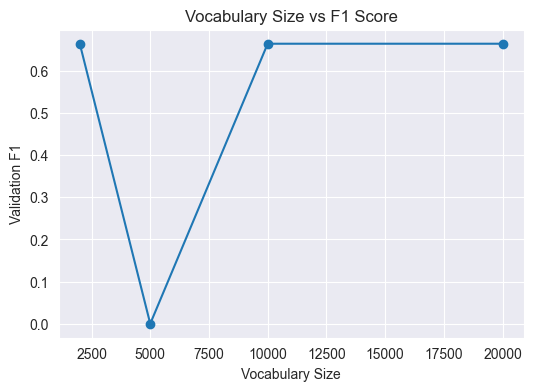

In [25]:
vocab_sizes, f1_scores = zip(*f1_results)
plt.figure(figsize=(6,4))
plt.plot(vocab_sizes, f1_scores, marker='o')
plt.xlabel('Vocabulary Size')
plt.ylabel('Validation F1')
plt.title('Vocabulary Size vs F1 Score')
plt.grid(True)
plt.show()